In [1]:
!python3 -V

Python 3.10.12


# RFDETR-m Medium

#### 需要留意的是，RFDETR通常在20epoch內就達到最高mAP，之後訓練都無法再進步了！

In [7]:
import os
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

# 直接讀取檔案
log_path = '/home/USER/Data/md_coco2yolo/runs/detect/RFDETR-m-e4-ep7map635/events.out.tfevents.1780192197.hgpn44.3949949.0'
ea = EventAccumulator(log_path)
ea.Reload()

# 看看裡面有哪些標籤 (例如 'train/loss', 'val/mAP')
# print("可用標籤:", ea.Tags()['scalars'])

# 範例：取出 'loss' 並畫圖 (請將 'loss' 換成你實際看到的標籤名)
tag = 'loss' 
if tag in ea.Tags()['scalars']:
    data = ea.Scalars(tag)
    steps = [d.step for d in data]
    values = [d.value for d in data]
    
    plt.plot(steps, values)
    plt.title(tag)
    plt.show()


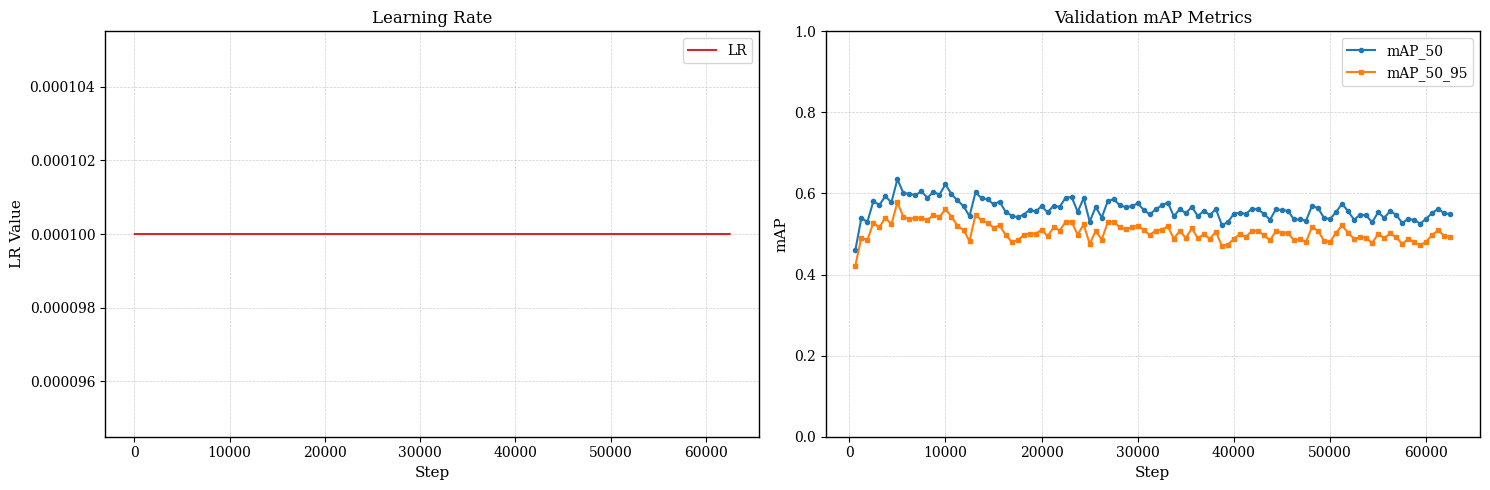

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 定義要抓取的標籤
target_tags = ['train/lr', 'val/mAP_50_95', 'val/mAP_50']
data_dict = {}

# 2. 提取數據
for tag in target_tags:
    if tag in ea.Tags()['scalars']:
        events = ea.Scalars(tag)
        data_dict[tag] = {
            'step': [e.step for e in events],
            'value': [e.value for e in events]
        }

# 3. 繪製圖表 (建立 1 列 2 欄的圖表)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 圖左：繪製 Learning Rate
if 'train/lr' in data_dict:
    ax1.plot(data_dict['train/lr']['step'], data_dict['train/lr']['value'], color='tab:red', label='LR')
    ax1.set_title('Learning Rate')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('LR Value')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

# 圖右：繪製 mAP 變化的趨勢
if 'val/mAP_50' in data_dict:
    ax2.plot(data_dict['val/mAP_50']['step'], data_dict['val/mAP_50']['value'], label='mAP_50', marker='o', markersize=3)
if 'val/mAP_50_95' in data_dict:
    ax2.plot(data_dict['val/mAP_50_95']['step'], data_dict['val/mAP_50_95']['value'], label='mAP_50_95', marker='s', markersize=3)

ax2.set_title('Validation mAP Metrics')
ax2.set_xlabel('Step')
ax2.set_ylabel('mAP')
ax2.set_ylim(0, 1.0) # mAP 通常在 0~1 之間
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

# 4. 額外：如果您想看每個 Epoch 對應的數值清單 (使用 Pandas)
df_map = pd.DataFrame({
    'Step': data_dict['val/mAP_50']['step'],
    'mAP_50': data_dict['val/mAP_50']['value'],
    'mAP_50_95': data_dict['val/mAP_50_95']['value']
})
# print("\n--- 最近 5 個紀錄點的數據 ---")
# print(df_map.tail())
# print("\n--- 所有 紀錄點的數據 ---")
# print(df_map)

# RFDETR-s SMALL

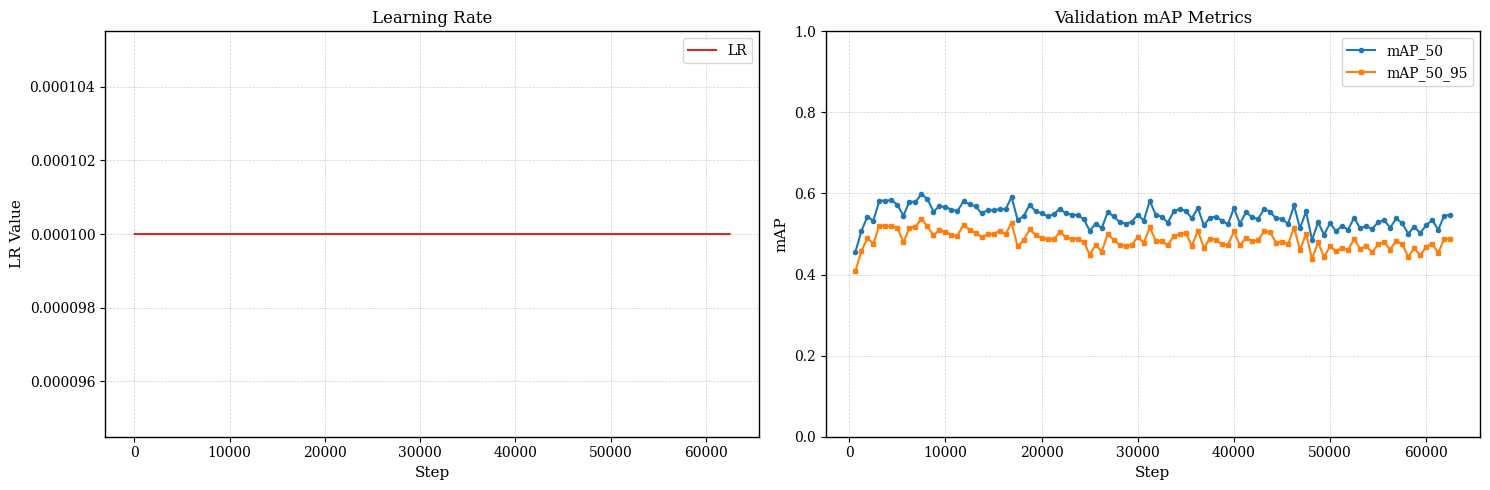

In [10]:
import os
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

# 直接讀取檔案
log_path = '/home/USER/Data/md_coco2yolo/runs/detect/RFDETR-s/events.out.tfevents.1780282028.hgpn44.1631099.0'
ea = EventAccumulator(log_path)
ea.Reload()

# 看看裡面有哪些標籤 (例如 'train/loss', 'val/mAP')
# print("可用標籤:", ea.Tags()['scalars'])

# 範例：取出 'loss' 並畫圖 (請將 'loss' 換成你實際看到的標籤名)
tag = 'loss' 
if tag in ea.Tags()['scalars']:
    data = ea.Scalars(tag)
    steps = [d.step for d in data]
    values = [d.value for d in data]
    
    plt.plot(steps, values)
    plt.title(tag)
    plt.show()


import matplotlib.pyplot as plt
import pandas as pd

# 1. 定義要抓取的標籤
target_tags = ['train/lr', 'val/mAP_50_95', 'val/mAP_50']
data_dict = {}

# 2. 提取數據
for tag in target_tags:
    if tag in ea.Tags()['scalars']:
        events = ea.Scalars(tag)
        data_dict[tag] = {
            'step': [e.step for e in events],
            'value': [e.value for e in events]
        }

# 3. 繪製圖表 (建立 1 列 2 欄的圖表)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 圖左：繪製 Learning Rate
if 'train/lr' in data_dict:
    ax1.plot(data_dict['train/lr']['step'], data_dict['train/lr']['value'], color='tab:red', label='LR')
    ax1.set_title('Learning Rate')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('LR Value')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

# 圖右：繪製 mAP 變化的趨勢
if 'val/mAP_50' in data_dict:
    ax2.plot(data_dict['val/mAP_50']['step'], data_dict['val/mAP_50']['value'], label='mAP_50', marker='o', markersize=3)
if 'val/mAP_50_95' in data_dict:
    ax2.plot(data_dict['val/mAP_50_95']['step'], data_dict['val/mAP_50_95']['value'], label='mAP_50_95', marker='s', markersize=3)

ax2.set_title('Validation mAP Metrics')
ax2.set_xlabel('Step')
ax2.set_ylabel('mAP')
ax2.set_ylim(0, 1.0) # mAP 通常在 0~1 之間
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

# 4. 額外：如果您想看每個 Epoch 對應的數值清單 (使用 Pandas)
df_map = pd.DataFrame({
    'Step': data_dict['val/mAP_50']['step'],
    'mAP_50': data_dict['val/mAP_50']['value'],
    'mAP_50_95': data_dict['val/mAP_50_95']['value']
})
# print("\n--- 最近 5 個紀錄點的數據 ---")
# print(df_map.tail())
# print("\n--- 所有 紀錄點的數據 ---")
# print(df_map)

# YOLOs

【成功】已儲存高品質 600 DPI 圖片：
1. ./train_yolo11n_metrics.png
2. ./train_yolo11n_metrics.pdf


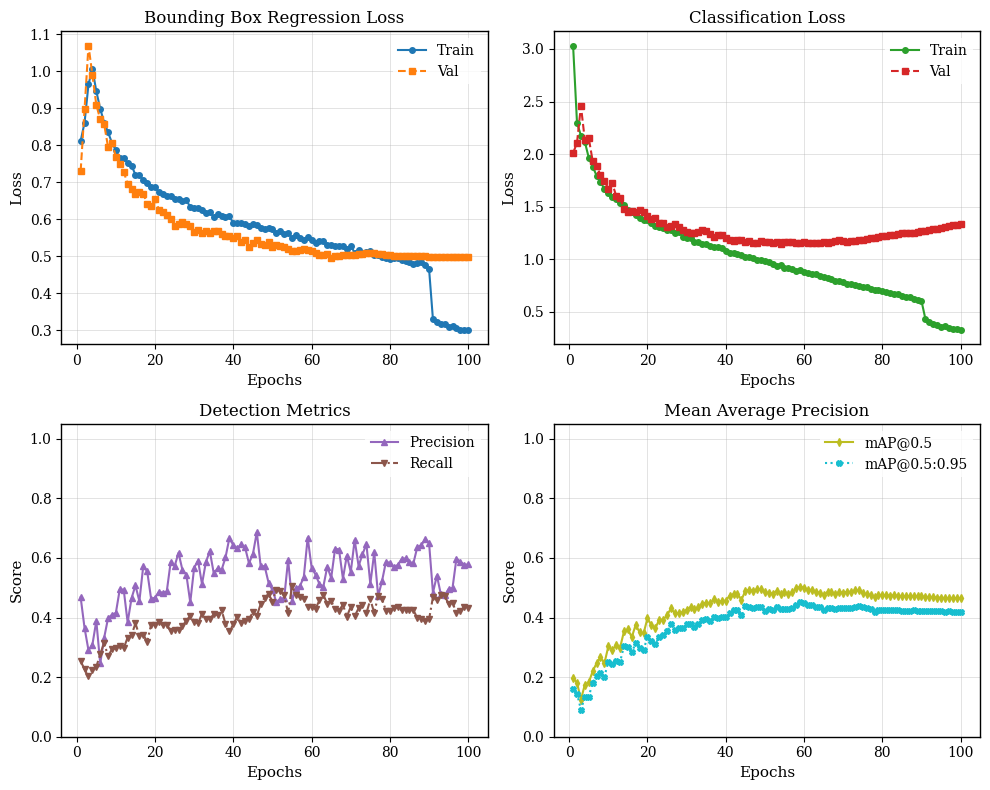

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==========================================
# 1. 檔案路徑與變數解析
# ==========================================
# 檔案路徑
log_path = '/home/USER/Data/md_coco2yolo/runs/detect/train_yolo11n/results.csv'
# log_path = '/home/USER/Data/md_coco2yolo/runs/detect/train_yolo26n/results.csv'
# log_path = '/home/USER/Data/md_coco2yolo/runs/detect/train_yolo26x/results.csv'
# log_path = '/home/USER/Data/md_coco2yolo/runs/detect/train_yolo26x960/results.csv'
model_name = Path(log_path).parent.name  # 自動提取 'train_yolo11n'

df = pd.read_csv(log_path)
df.columns = df.columns.str.strip()

# ==========================================
# 2. 圖表風格設定 
# ==========================================
# 使用經典的 serif (襯線體)，預設會尋找 Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'  # 數學公式字體

# 嚴格控制字體大小，確保印刷品質
plt.rcParams['axes.labelsize'] = 11      # X/Y 軸標籤
plt.rcParams['axes.titlesize'] = 12      # 子圖標題
plt.rcParams['xtick.labelsize'] = 10     # X 軸刻度
plt.rcParams['ytick.labelsize'] = 10     # Y 軸刻度
plt.rcParams['legend.fontsize'] = 10     # 圖例字體

# 設定線條與邊框
plt.rcParams['axes.linewidth'] = 1.0     # 坐標軸線條粗細
plt.rcParams['grid.linewidth'] = 0.5     # 網格線粗細
plt.rcParams['grid.alpha'] = 0.5         # 網格線透明度

# ==========================================
# 3. 開始繪圖 (改為 2x2 矩陣，滿版排版)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# --- 圖 (a): Bounding Box Loss ---
axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train', color='#1f77b4', linewidth=1.5, marker='o', markersize=4)
axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val', color='#ff7f0e', linewidth=1.5, linestyle='--', marker='s', markersize=4)
axes[0, 0].set_title('Bounding Box Regression Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True)
axes[0, 0].legend(frameon=True, edgecolor='none')

# --- 圖 (b): Classification Loss ---
axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train', color='#2ca02c', linewidth=1.5, marker='o', markersize=4)
axes[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Val', color='#d62728', linewidth=1.5, linestyle='--', marker='s', markersize=4)
axes[0, 1].set_title('Classification Loss')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True)
axes[0, 1].legend(frameon=True, edgecolor='none')

# --- 圖 (c): Precision & Recall ---
axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='#9467bd', linewidth=1.5, marker='^', markersize=4)
axes[1, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='#8c564b', linewidth=1.5, linestyle='-.', marker='v', markersize=4)
axes[1, 0].set_title('Detection Metrics')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].grid(True)
axes[1, 0].legend(frameon=True, edgecolor='none')

# --- 圖 (d): mAP50 & mAP50-95 ---
axes[1, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5', color='#bcbd22', linewidth=1.5, marker='d', markersize=4)
axes[1, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', color='#17becf', linewidth=1.5, linestyle=':', marker='X', markersize=4)
axes[1, 1].set_title('Mean Average Precision')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].grid(True)
axes[1, 1].legend(frameon=True, edgecolor='none')

# 調整子圖間距
plt.tight_layout()

# ==========================================
# 4. 存檔 (同時儲出 PNG 與 PDF 向量圖)
# ==========================================
output_png = f'./{model_name}_metrics.png'
plt.savefig(output_png, dpi=600, format='png', bbox_inches='tight', pad_inches=0.05)

# 輸出無限解析度的 PDF 向量圖
output_pdf = f'./{model_name}_metrics.pdf'
plt.savefig(output_pdf, format='pdf', bbox_inches='tight', pad_inches=0.05)

print(f"【成功】已儲存高品質 600 DPI 圖片：\n1. {output_png}\n2. {output_pdf}")
plt.show()